![hslu_logo.png](img/hslu_logo.png)

## Week 04

<hr style="border:1px solid black">

# PyTorch DataSet and DataLoader
---
---
We will study the Datset and DataLoader classes for access to the predefined and own data [Datasets&DataLoaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).

In [1]:
import torch
import torchvision
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import time

from utils import plot_img, plot_tiles, create_file_frame

### Preparation for DataLoader below 
We will use a torch DataLoader below, which can do plenty of things - in particular the data normaliation using a transform function

In [2]:
#import shortcut (just for here)
from torchvision.transforms import v2

my_transform = v2.Compose([
    v2.ToImage(),  # Convert to tensor, data are PIL images
    v2.ToDtype(torch.float32, scale=False),  # convert to float; optionally normalize data 
                                            # (if True choose mean=[0.5], std=[0.5] below (why?)
    v2.Normalize(mean=[128.], std=[128.]),
])

In [3]:
#only at first execution data is downloaded, because it is saved in subfolder ../week1/data; 
#note the relative path to the 01.learning-optimization to avoid multiple downloads
data_set = 'FashionMNIST'
    
if data_set == 'MNIST':
    training_data = torchvision.datasets.MNIST(
        root="../SW01/data",
        train=True,
        download=True,
        transform=my_transform
    )

    test_data = torchvision.datasets.MNIST(
        root="../SW01/data",
        train=False,
        download=True,
        transform=my_transform
    )    

    #labels for MNIST (just for compatibility reasons)
    labels_map = {
        0: "Zero",
        1: "One",
        2: "Two",
        3: "Three",
        4: "Four",
        5: "Five",
        6: "Six",
        7: "Seven",
        8: "Eight",
        9: "Nine",
    }
else:
    training_data = torchvision.datasets.FashionMNIST(
        root="../SW01/data",
        train=True,
        download=True,
        transform=my_transform
    )

    test_data = torchvision.datasets.FashionMNIST(
        root="../SW01/data",
        train=False,
        download=True,
        transform=my_transform
    )

    #labels for FashionMNIST
    labels_map = {
        0: "T-Shirt",
        1: "Trouser",
        2: "Pullover",
        3: "Dress",
        4: "Coat",
        5: "Sandal",
        6: "Shirt",
        7: "Sneaker",
        8: "Bag",
        9: "Ankle Boot",
    }

### Verify Dataset type

We check that the training data instance is of type Dataset

In [4]:
from torch.utils.data import Dataset

print(isinstance(training_data, Dataset))
print(hasattr(training_data, '__len__'))
print(hasattr(training_data, '__getitem__'))

True
True
True


### Verify transform property

We check that the training data instance has the transform method

In [5]:
print(hasattr(training_data, 'transform'))

True


### Illustration of DataLoder concept


In [6]:
# dataloaders (we use original set (training/test_data); own data has to realize the abstract class representing 'Dataset'
train_loader = torch.utils.data.DataLoader(training_data, batch_size=256, shuffle=True)


In [7]:
#setup iterator
data_iterator = iter(train_loader)

#fetch first batch of images (and corresponding labels)
images, labels = next(data_iterator)

#note that the images are a 4-dim tensor; first dimension is image index in batch, second is number of channels (colors)
print(images.shape)
print(labels.shape)
#print first ten labels -> change 'shuffle=True' to 'shuffle=False' to check that order will be always the same
print(labels[:10])


torch.Size([256, 1, 28, 28])
torch.Size([256])
tensor([0, 3, 9, 9, 0, 6, 1, 2, 5, 4])


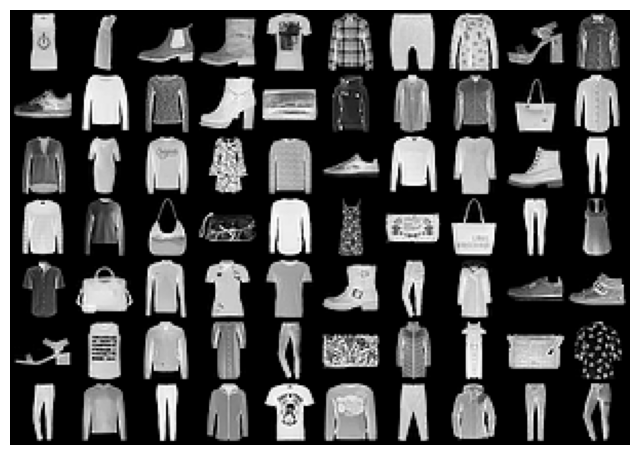

In [8]:
#plot a set of images; we rescale to avoid warning conc. data range
plot_tiles((images[:70] - images.min())/(images.max() - images.min()))

### Check the application of the transformation

In [9]:
#original data
print('tpye of original data: %r' % training_data.data.dtype)
print('min value of original data: %r' % torch.min(training_data.data).item())
print('max value of original data: %r' % torch.max(training_data.data).item())

#loaded data
print('\ntpye of loaded data: %r' % images.dtype)
print('min value of loaded data: %r' % torch.min(images).item())
print('max value of loaded data: %r' % torch.max(images).item())
#why is upper value not 1?

tpye of original data: torch.uint8
min value of original data: 0
max value of original data: 255

tpye of loaded data: torch.float32
min value of loaded data: -1.0
max value of loaded data: 0.9921875


In [10]:
#setup loop over all batchs
data_iterator = iter(train_loader)

start=time.time()
#note shape of last batch
print('shape of image batches:')
for batch_iter in data_iterator:
    print(batch_iter[0].numpy().shape)
    
end=time.time()
print('time for transforming entire batch: %2.1f s' % (end-start))

shape of image batches:
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1, 28, 28)
(256, 1

### Create custom dataset

Below we illustrate how to define our own dataset which will allow to read own data efficiently.

**Prepration of data**

Data is organised in subfolders of a `root_folder`, each subfolder corresponding to a category. Two sets exist which are the `train` and the `test` set.

The function `create_file_frame` (in `utils.py`) iterates through these folders and returns a pandas dataframe (mainly a two-column list) with the image paths and corresponding labels (as integer values). In addition `csv`-files in the `root_folder` are created with the same information.

In [11]:
categories = ['apple_braeburn', 'apple_golden_delicious', 'apple_topaz', 'peach', 'pear']
root_folder = 'food'

pdFrames, num_categories = create_file_frame(root_folder, categories)

#### Actual DataSet class definition

In [12]:
class MyDataset(Dataset):
    def __init__(self, pd_frame_info, img_dir, transform=None, target_transform=None):
        #can be either file or frames
        if type(pd_frame_info) == pd.core.frame.DataFrame:
            self.img_labels = pd_frame_info
        else:
            self.img_labels = pd.read_csv(pd_frame_info)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = torchvision.io.read_image(img_path, 
                                        mode=torchvision.io.image.ImageReadMode.RGB)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label
        

#### Define a new set of transforms

Image is 300x400 so we center crop a square size; in addition we rescale to 128x128

In [13]:
image_size = 128

#resize images and do scaling (size and channels) 
my_transform_2 = v2.Compose([
    v2.CenterCrop((300,300)),
    v2.Resize(size=[image_size,image_size], antialias=True),  
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

#### Create own DataSet and corresponding DataLoader instance

In [14]:
#now create a custom dataset based on the training dataset (we do the same later for the validation and testset)
my_dataset = MyDataset(pdFrames['train'], root_folder, my_transform_2)

train_loader = torch.utils.data.DataLoader(my_dataset, batch_size=30, shuffle=True)

#setup iterator
data_iterator = iter(train_loader)

#fetch first batch of images (and corresponding labels)
images, labels = next(data_iterator)

#note that the images are a 4-dim tensor; first dimension is image index in batch, second is number of channels (colors)
print(images.shape)
print(labels.shape)
#print first ten labels -> change 'shuffle=True' to 'shuffle=False' to check that order will be always the same
print(labels[:10])


torch.Size([30, 3, 128, 128])
torch.Size([30])
tensor([3, 3, 3, 3, 3, 3, 4, 4, 4, 4])


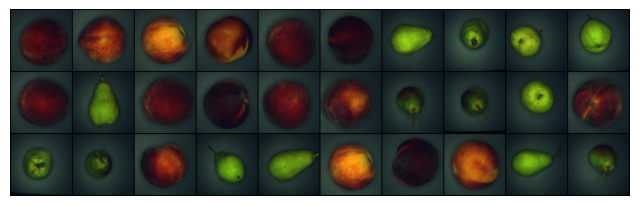

In [15]:
#plot a set of images; we rescale to avoid warning conc. data range
plot_tiles((images - images.min())/(images.max() - images.min()))

### Data Augmentation

Below we show how to implement data augmentation through the use of the `torchvision.transforms` class.

In [16]:
image_size = 250

#transformations including augmentation used for training
train_transform = v2.Compose([
    #rotation [-25°, 25°], scaling [0.75, 1.25], shear [-15°, 15°]
    v2.RandomAffine(degrees=25, scale=(0.75,1.25), shear=15),
    v2.CenterCrop((300,300)),
    v2.Resize(size=(image_size, image_size), antialias=True),
    #horizontal flip with 50% probability
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [17]:
#now create a custom dataset based on the training dataset (we do the same later for the validation and testset)
my_dataset = MyDataset(pdFrames['train'], root_folder, train_transform)

train_loader = torch.utils.data.DataLoader(my_dataset, batch_size=16, shuffle=True)

#setup iterator
data_iterator = iter(train_loader)

#fetch first batch of images (and corresponding labels)
images, labels = next(data_iterator)

#### Show images with augmentation

Each exection of the following cell will reproduce a new batch of 16 image with the different augmentation

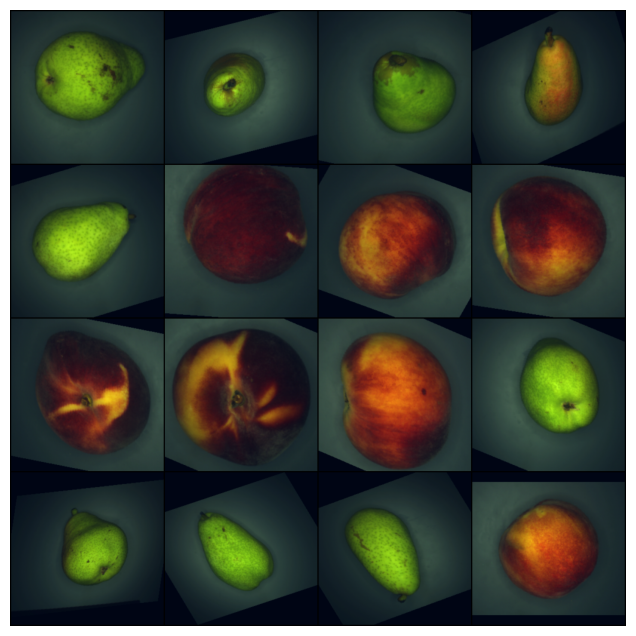

In [21]:
images, labels = next(data_iterator)
#plot a set of images; we rescale to avoid warning conc. data range
plot_tiles((images - images.min())/(images.max() - images.min()), cols=4)